# Моделирование температуры сплава в тигель ковше
Выпускной проект

## Описание
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать. 

## План работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import optuna

pd.set_option('display.max_columns', 100)

## Загрузка данных

In [2]:
def load_dataset(name, parse_dates=None, sep=',', decimal='.'):
	df = pd.DataFrame()
	try:
		df = pd.read_csv(f'./datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из локальной папки')
	except:
		df = pd.read_csv(f'https://code.s3.yandex.net/datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из облака')
	df.sort_index(inplace=True)
	return df

In [3]:
data_arc		= load_dataset('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk		= load_dataset('data_bulk')
data_bulk_time	= load_dataset('data_bulk_time', parse_dates=list(range(1, data_bulk.shape[1] + 1)))
data_gas		= load_dataset('data_gas')
data_temp		= load_dataset('data_temp', parse_dates=[1])
data_wire		= load_dataset('data_wire')
data_wire_time	= load_dataset('data_wire_time', parse_dates=list(range(1, data_wire.shape[1] + 1)))

data_arc загружен из локальной папки
data_bulk загружен из локальной папки
data_bulk_time загружен из локальной папки
data_gas загружен из локальной папки
data_temp загружен из локальной папки
data_wire загружен из локальной папки
data_wire_time загружен из локальной папки


## Осмотр данных

In [4]:
"""
Рисует гистограмму и ящик с усами для количественных непрерывных признаков
"""
def plot_col(df, col, axs, cat_target):
	ax = sns.histplot(data=df, x=col, hue=cat_target, bins=50, ax=axs[0]);
	ax.set_xlabel(None)
	ax.set_ylabel(col)
	ax = sns.boxplot(data=df, x=col, ax=axs[1]);
	ax.set_yticklabels([])
	ax.set_xlabel(None)

def plot_num_cont(df_raw, cols=None, cat_target=None):
	df = df_raw.reset_index(drop=True)
	if not cols: cols = df.select_dtypes(include='float64').columns
	row_count = len(cols)
	if row_count == 0:
		return
	fig, axs = plt.subplots(row_count, 2)
	fig.set_size_inches(12, 3 * row_count)
	if len(cols) == 1:
		plot_col(df, cols[0], axs, cat_target)
	else:
		row_idx = 0
		for col in cols:
			plot_col(df, col, axs[row_idx], cat_target)
			row_idx += 1

def explore_df(df):
	print('-' * 100)
	print('sample:')
	display(df.sample(5))
	print('-' * 100)
	print('\ninfo:\n')
	df.info()
	print('-' * 100)
	print('\ndescribe:\n')
	display(df.describe())
	print('-' * 100)
	print('\nduplicates:\n')
	print(f'id duplicates: {df.index.duplicated().sum()}, full row duplicates: {df.duplicated().sum()}')
	print('-' * 100)
	print('\nunique keys:\n')
	print(df.index.unique().size)
	plot_num_cont(df)

### data_arc
данные о нагреве электродами

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

----------------------------------------------------------------------------------------------------
sample:


,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
key,,,,
2438,2019-08-08 08:33:47,2019-08-08 08:35:08,0.679074,0.545716
2536,2019-08-11 17:37:49,2019-08-11 17:39:00,0.863575,0.673495
2809,2019-08-22 05:04:11,2019-08-22 05:07:55,0.807647,0.579543
329,2019-05-16 05:28:09,2019-05-16 05:29:18,0.380727,0.317402
1388,2019-06-24 19:48:06,2019-06-24 19:52:09,0.324493,0.205169


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Начало нагрева дугой  14876 non-null  datetime64[ns]
 1   Конец нагрева дугой   14876 non-null  datetime64[ns]
 2   Активная мощность     14876 non-null  float64       
 3   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB
----------------------------------------------------------------------------------------------------

describe:



,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876,14876,14876.000000,14876.000000
mean,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,NaN,NaN,0.258885,5.873485


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 11662, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3214


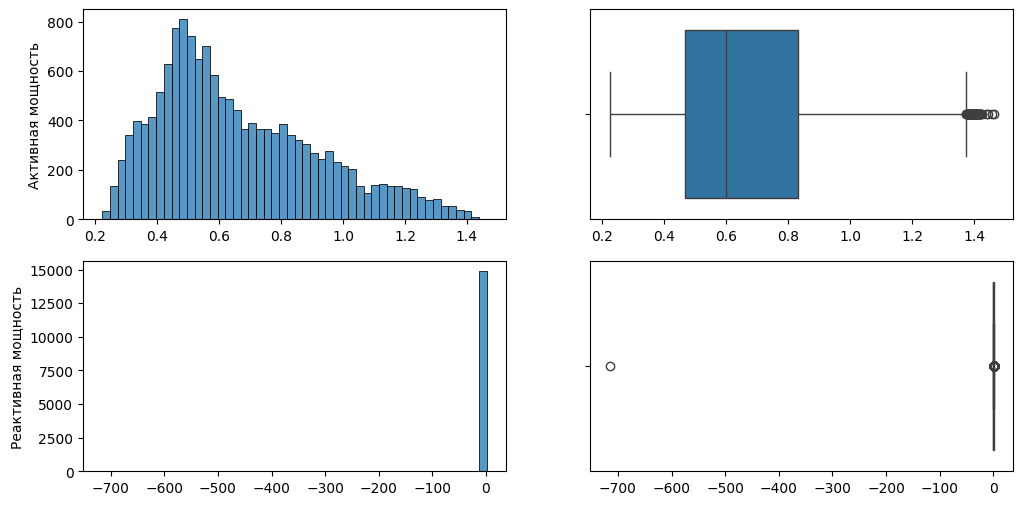

In [5]:
explore_df(data_arc)

- каждая запись - один цикл нагрева ковша с времением начала и конца и параметрами мощности
- по каждому ковшу как правило есть несколько записей - несколько циклов
- аномальный минимум в Реактивной мощности
- пропусков нет
- полных дубликатов нет

### data_bulk
данные о подаче сыпучих материалов (объём)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
2157,NaN,NaN,99.0,67.0,NaN,NaN,NaN,NaN,NaN,61.0,NaN,329.0,NaN,196.0,190.0
2328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,NaN,207.0,NaN,91.0,106.0
1278,NaN,NaN,NaN,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,124.0,103.0
1241,27.0,NaN,NaN,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253.0,NaN,125.0,205.0
868,NaN,NaN,89.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,104.0,104.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB
----------------------------------------------------------------------------------------------------

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 80
----------------------------------------------------------------------------------------------------

unique keys:

3129


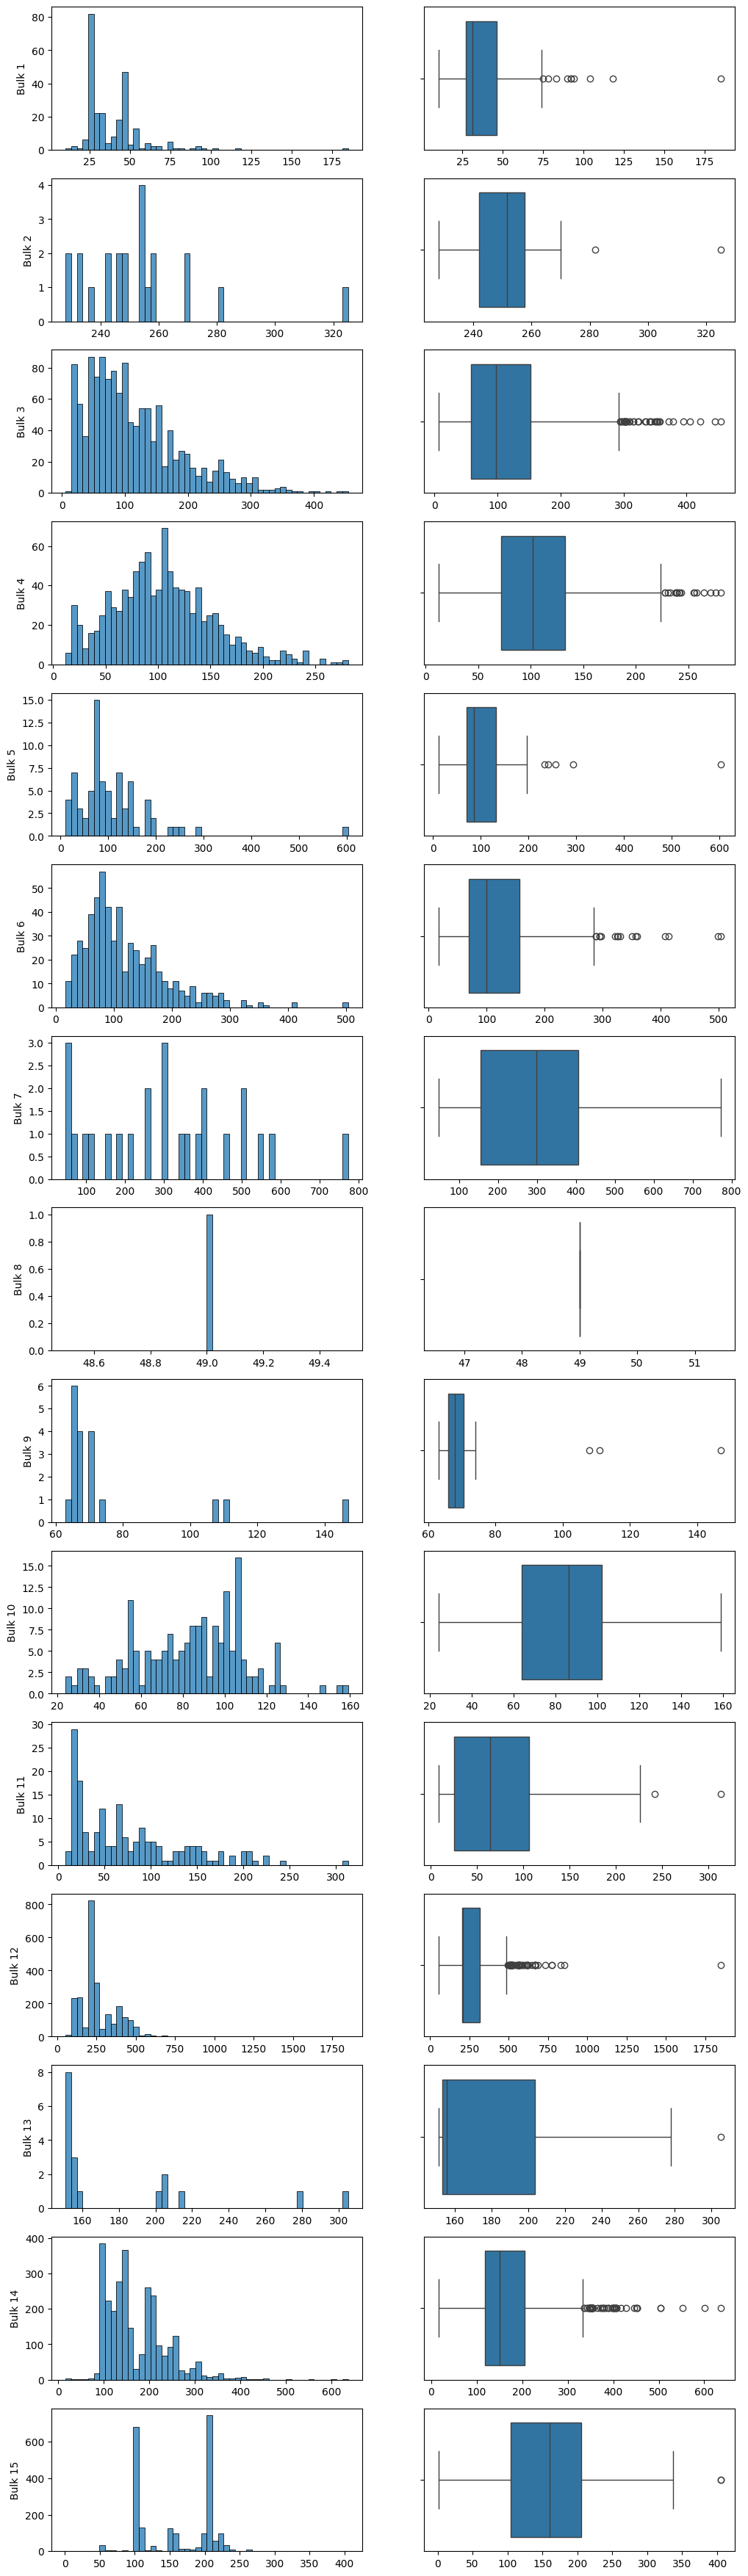

In [6]:
explore_df(data_bulk)

- здесь один ковш - одна запись. колонки по всей видимости соответствуют различным материалам - их поданному в ковш объему
- пропуски видимо значат, что такой материал не применялся, т.е. стоит заменить их на 0
- оценить здесь, что есть выбросы, без дополнительной информации сложно, но явных (отрицательных или огромных, нет)
- дубликатов по ключу нет

### data_bulk_time
данные о подаче сыпучих материалов (время)

In [7]:
explore_df(data_bulk_time)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
825,NaT,NaT,2019-06-04 16:53:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-04 16:53:48,NaT,2019-06-04 16:59:18,2019-06-04 16:53:48
1991,NaT,NaT,NaT,2019-07-23 01:53:06,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2229,NaT,NaT,NaT,2019-07-31 20:09:06,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-07-31 20:01:11,NaT,2019-07-31 19:48:11,2019-07-31 19:41:52
1413,2019-06-25 15:52:45,NaT,2019-06-25 16:05:49,NaT,NaT,2019-06-25 16:05:49,NaT,NaT,NaT,NaT,NaT,2019-06-25 16:05:49,NaT,2019-06-25 16:05:49,2019-06-25 16:05:49
1131,NaT,NaT,2019-06-15 13:22:26,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-15 13:32:11,NaT,2019-06-15 13:32:11,2019-06-15 13:22:26


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 1   252 non-null    datetime64[ns]
 1   Bulk 2   22 non-null     datetime64[ns]
 2   Bulk 3   1298 non-null   datetime64[ns]
 3   Bulk 4   1014 non-null   datetime64[ns]
 4   Bulk 5   77 non-null     datetime64[ns]
 5   Bulk 6   576 non-null    datetime64[ns]
 6   Bulk 7   25 non-null     datetime64[ns]
 7   Bulk 8   1 non-null      datetime64[ns]
 8   Bulk 9   19 non-null     datetime64[ns]
 9   Bulk 10  176 non-null    datetime64[ns]
 10  Bulk 11  177 non-null    datetime64[ns]
 11  Bulk 12  2450 non-null   datetime64[ns]
 12  Bulk 13  18 non-null     datetime64[ns]
 13  Bulk 14  2806 non-null   datetime64[ns]
 14  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](1

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3129


- у data_bulk_time структура такая же, как у data_bulk
- дубликатов по ключу нет

### data_gas
данные о продувке сплава газом

----------------------------------------------------------------------------------------------------
sample:


,Газ 1
key,
538,8.178137
1752,16.516660
43,7.340330
1015,5.328151
1450,5.850393


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Газ 1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB
----------------------------------------------------------------------------------------------------

describe:



,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3239


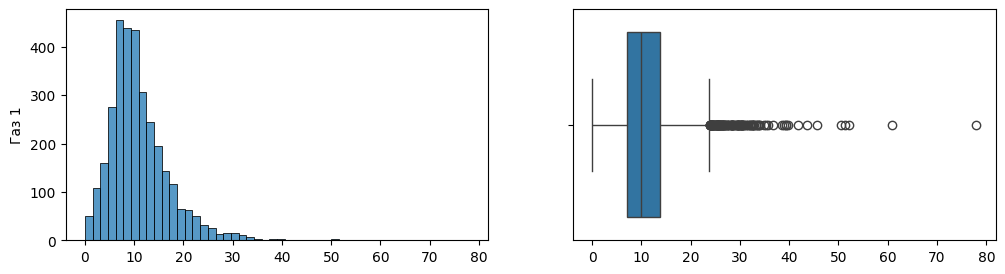

In [8]:
explore_df(data_gas)

- data_gas - просто какой объем газа (видимо, в сумме) был продут через каждый ковш
- дубликатов нет
- лакун нет
- явных выбросов нет

### data_temp
результаты измерения температуры

----------------------------------------------------------------------------------------------------
sample:


,Время замера,Температура
key,,
2106,2019-07-27 06:38:51,1601.0
1946,2019-07-20 19:27:19,1568.0
1652,2019-07-04 03:18:20,1591.0
2993,2019-08-29 04:22:54,NaN
1199,2019-06-17 21:23:59,1637.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 18092 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Время замера  18092 non-null  datetime64[ns]
 1   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 424.0 KB
----------------------------------------------------------------------------------------------------

describe:



,Время замера,Температура
count,18092,14665.000000
mean,2019-07-05 13:36:58.791620608,1590.722741
min,2019-05-03 11:02:04,1191.000000
25%,2019-06-04 00:35:01.249999872,1580.000000
50%,2019-07-03 02:11:48,1590.000000
75%,2019-08-07 23:10:05.249999872,1599.000000
max,2019-09-06 17:30:05,1705.000000
std,NaN,20.394381


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 14876, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3216


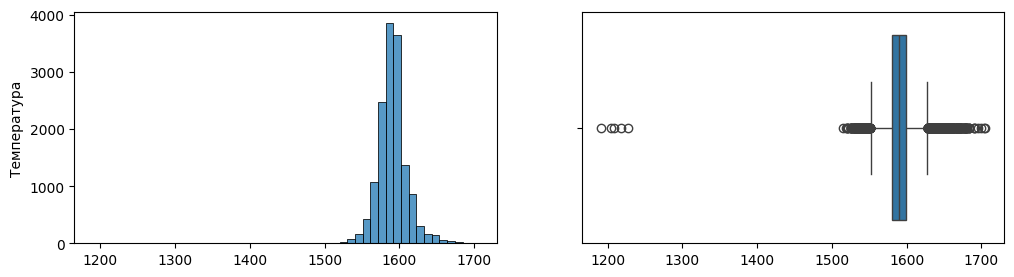

In [9]:
explore_df(data_temp)

- в data_temp каждая запись - один замер (время и температура). как правило по несколько замеров для каждого ковша.
- есть лакуны в поле температуры
- есть значения заведомо ниже температуры плавления сплава (~1400), чего быть не должно - сплав застынет и все - будем считать выбросами
- если не считать выбросы, распределение похоже на нормальное с чуть более вытянутым хвостом в сторону высоких температур

### data_wire
данные о проволочных материалах (объём)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1264,134.128800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3184,100.114563,25.153439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524,54.147598,51.030720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790,116.110802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
554,148.215607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 403
----------------------------------------------------------------------------------------------------

unique keys:

3081


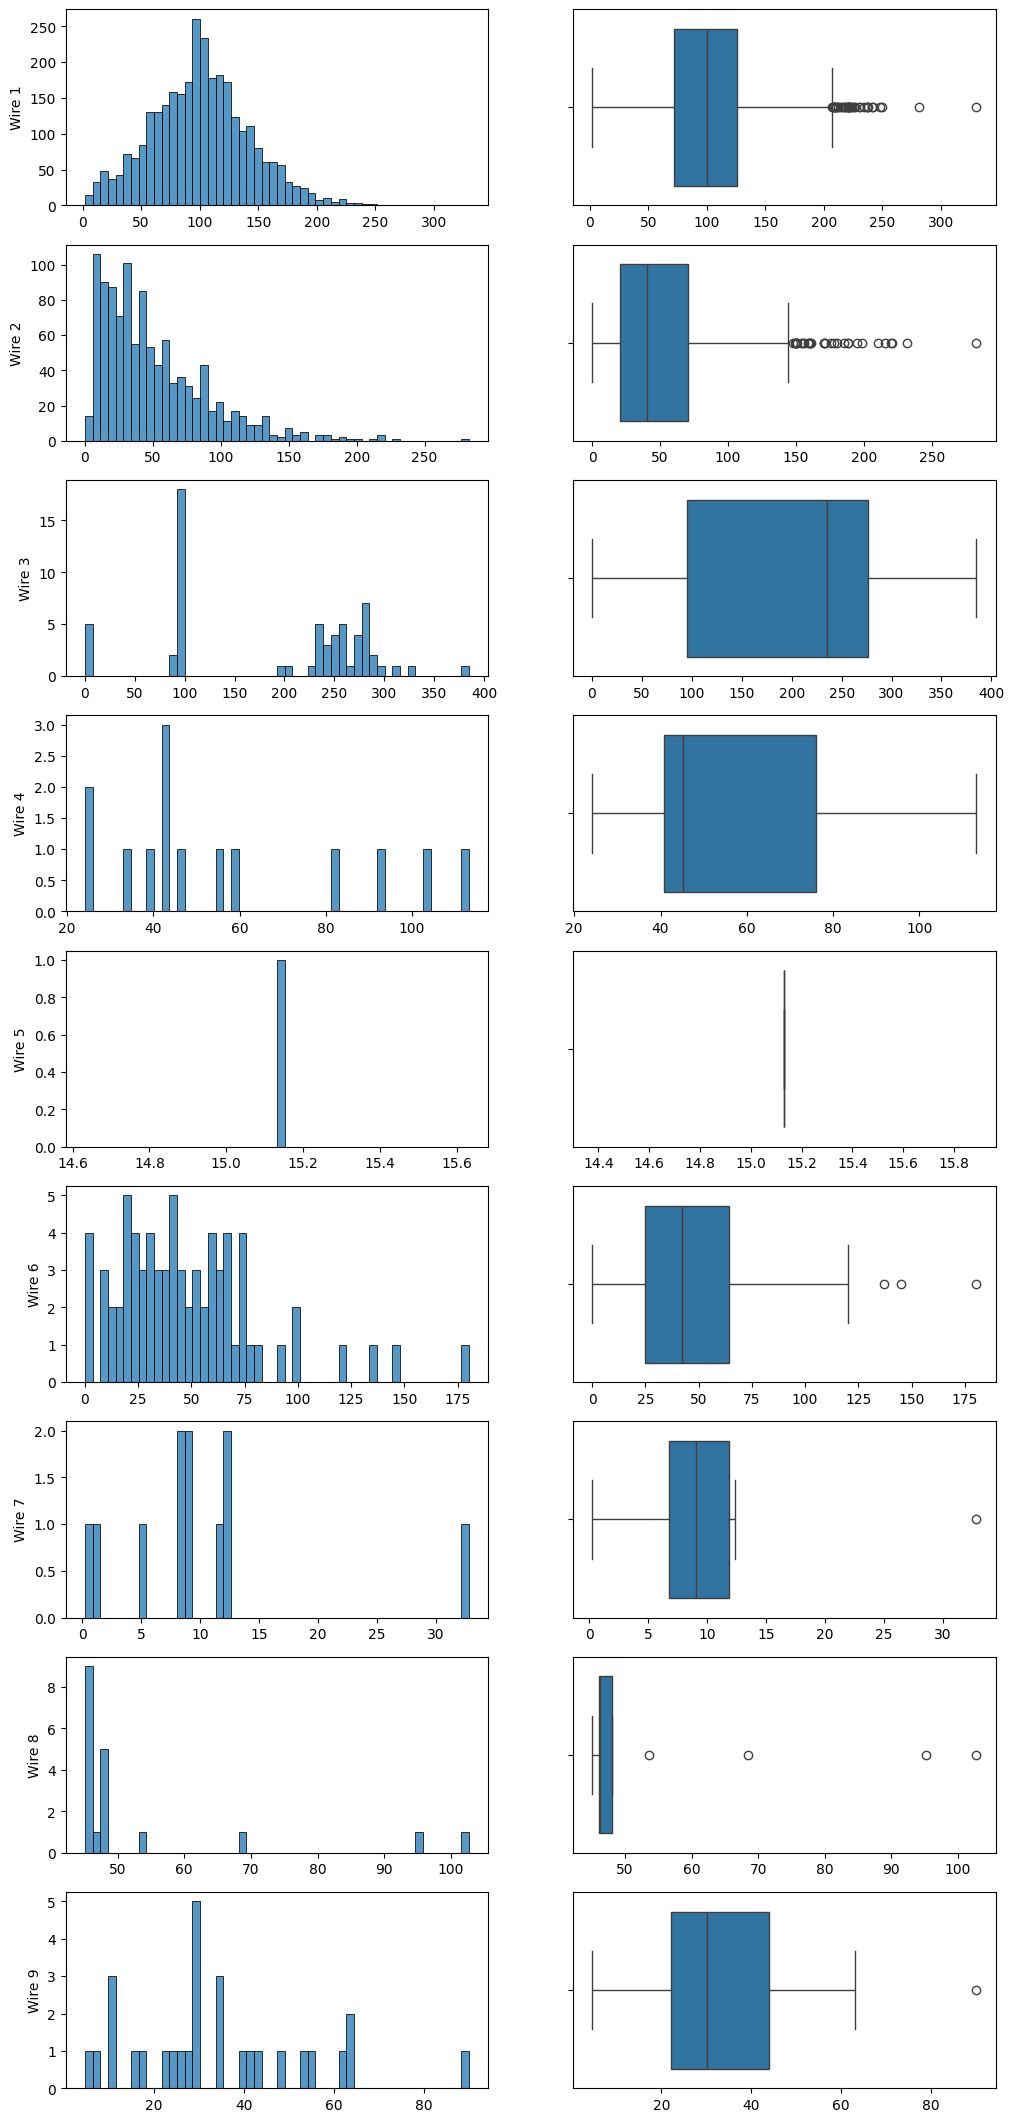

In [10]:
explore_df(data_wire)

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов
- дубликатов по ключу нет

### data_wire_time
данные о проволочных материалах (время)

In [11]:
explore_df(data_wire_time)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
3234,2019-09-06 09:43:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
372,2019-05-17 23:14:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1626,2019-07-03 07:32:00,2019-07-03 07:23:10,NaT,NaT,NaT,NaT,NaT,NaT,NaT
996,2019-06-10 22:03:05,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
358,2019-05-17 11:14:08,2019-05-17 11:04:05,NaT,NaT,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
 2   Wire 3  63 non-null     datetime64[ns]
 3   Wire 4  14 non-null     datetime64[ns]
 4   Wire 5  1 non-null      datetime64[ns]
 5   Wire 6  73 non-null     datetime64[ns]
 6   Wire 7  11 non-null     datetime64[ns]
 7   Wire 8  19 non-null     datetime64[ns]
 8   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055,1079,63,14,1,73,11,19,29
mean,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3081


- data_wire_time - то же самое, что для data_wire

### Общие выводы по данным
- Есть две очевидные аномалии:
  - очень низкое значение в реактивной мощности
  - есть значения заведомо ниже температуры плавления сплава (~1400)
- Пропуски для bulk и wire надо заменить нулями
- Характер распределений здесь кроме температуры, наверное, описывать смысла нет, т.к. он определяется технологией процесса
- Желательно переименовать колонки в общепринятом стиле
- Хорошо бы найти метод определить время начала работы с ковшом, тогда можно попробовать перевести все времена для ковша в относительные к времени начала
- Для нагрева электродами можно посчитать продолжительность цикла и работу (активная мощность * продолжительность)
- Реактивная мощность по идее не должна влиять на температуру. Только на затраты энергии
- Дубликатов, которые надо убрать, как будто нет

## Предобработка данных
### Переименования колонок

In [12]:
data_arc.columns = ['arc_start_time', 'arc_end_time', 'arc_active_power', 'arc_reactive_power']
data_bulk.columns = [f'bulk_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_bulk_time.columns = [f'bulk_time_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_gas.columns = ['gas_1']
data_temp.columns = ['temp_time', 'temp']
data_wire.columns = [f'wire_{x:02}' for x in range(1, data_wire.shape[1] + 1)]
data_wire_time.columns = [f'wire_time_{x:02}' for x in range(1, data_wire.shape[1] + 1)]

for df in [data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time]:
	print(df.columns)

Index(['arc_start_time', 'arc_end_time', 'arc_active_power',
       'arc_reactive_power'],
      dtype='object')
Index(['bulk_01', 'bulk_02', 'bulk_03', 'bulk_04', 'bulk_05', 'bulk_06',
       'bulk_07', 'bulk_08', 'bulk_09', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')
Index(['bulk_time_01', 'bulk_time_02', 'bulk_time_03', 'bulk_time_04',
       'bulk_time_05', 'bulk_time_06', 'bulk_time_07', 'bulk_time_08',
       'bulk_time_09', 'bulk_time_10', 'bulk_time_11', 'bulk_time_12',
       'bulk_time_13', 'bulk_time_14', 'bulk_time_15'],
      dtype='object')
Index(['gas_1'], dtype='object')
Index(['temp_time', 'temp'], dtype='object')
Index(['wire_01', 'wire_02', 'wire_03', 'wire_04', 'wire_05', 'wire_06',
       'wire_07', 'wire_08', 'wire_09'],
      dtype='object')
Index(['wire_time_01', 'wire_time_02', 'wire_time_03', 'wire_time_04',
       'wire_time_05', 'wire_time_06', 'wire_time_07', 'wire_time_08',
       'wire_time_09'],
      d

### Убираем аномалии
- очень низкое значение в реактивной мощности
- значения заведомо ниже температуры плавления сплава (~1400)

,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power
key,,,,
2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


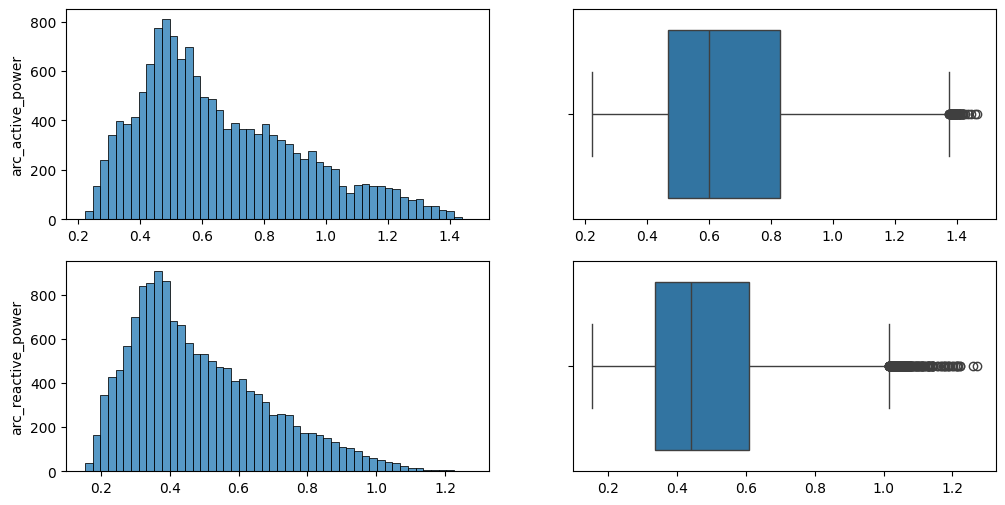

In [13]:
display(data_arc.query('arc_reactive_power < 0'))
data_arc.drop(index=data_arc.query('arc_reactive_power < 0').index, inplace=True)
plot_num_cont(data_arc)

,temp_time,temp
key,,
867,2019-06-06 08:03:39,1191.0
1214,2019-06-18 08:01:03,1208.0
1619,2019-07-03 02:34:41,1218.0
2052,2019-07-25 08:49:15,1227.0
2561,2019-08-12 18:49:29,1204.0


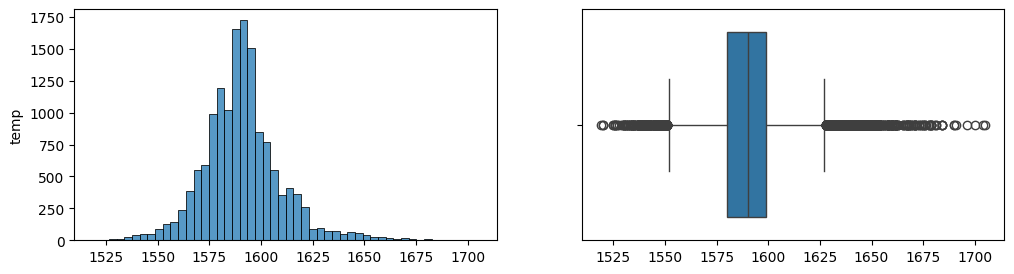

In [14]:
display(data_temp.query('temp < 1400'))
data_temp.drop(index=data_temp.query('temp < 1400').index, inplace=True)
plot_num_cont(data_temp)

### Заменяем пропуски на нули
Там, где это приемлемо: bulk и wire

In [15]:
data_bulk.fillna(value=0, inplace=True)
data_wire.fillna(value=0, inplace=True)
print(data_bulk.isna().sum().sum())
print(data_wire.isna().sum().sum())

0
0


### Удаляем пропуски
В data_temp есть пропуски температуры. Это таргет и измерений для каждого ковша несколько. Наверное, лучше просто удалить пропущенные значения.

In [16]:
data_temp.dropna(inplace=True)
print(data_temp.isna().sum().sum())

0


### Новые признаки в arc
В data_arc надо посчитать работу по нагреву. Т.к. именно от кол-ва джоулей зависит насколько изменится температура.

Для расчета работы возьмем только acive_power, без reacive_power. Т.к."тратится", и соотв. передает энергию только активная составляющая (ну почти только она - реактивная мощность вроде как тоже создает ток, который в среде, обладающей сопротивлением, теряет какую-то часть энергии в тепло, но это не точно).

Длительность нагрева выделим в отдельное поле.

Еще на всякий случай посчитаем полную (кажущуюся) мощность (корень суммы квадратов двух мощностей), и посмотрим, как ее влияение на температуру оценит модель.

In [17]:
data_arc.loc[:, 'arc_duration_sec'] = (data_arc['arc_end_time'] - data_arc['arc_start_time']).dt.seconds
data_arc.loc[:, 'arc_work'] = data_arc['arc_duration_sec'] * data_arc['arc_active_power']
data_arc[['arc_duration_sec', 'arc_active_power', 'arc_work']].sample(3)

,arc_duration_sec,arc_active_power,arc_work
key,,,
53,244,0.658706,160.724264
662,152,1.114490,169.402480
1239,83,0.621592,51.592136


In [18]:
data_arc.loc[:, 'arc_apparent_power'] = (data_arc['arc_active_power'] ** 2 + data_arc['arc_reactive_power'] ** 2) ** .5
data_arc['arc_apparent_power'].sample(3)

key
334     0.860986
1886    0.654156
1940    0.605970
Name: arc_apparent_power, dtype: float64

### Объединение данных
Попробуем такой подход: у нас для каждого ковша есть несколько измерений температуры в определенные моменты времени и есть данные по действиям, которые совершали над этим ковшом, тоже с указанием моментов времени. Можно сделать такие обучающие записи: предыдущая температура, результирующая температура, все действия, которые были произведены в промежуток времени между этими двумя измерениями температур.

Здесь, правда, есть теоретическая сложность: если время измерения температуры будет попадать в интервал нагрева, то работу по нагреву придется распределять по двум интервалам температур. Но по идее такого быть не должно: нагревали и измеряли, как будто не одновременно. Посмотрим.

Набор со всеми собранными данными будет называться *data_all*

#### Предыдущая температура в том же ковше
Добавим поля temp_time_prev, temp_prev - предыдущее измерение температуры в ковше. После этого записи с первыми измерениями удалим.

In [19]:
data_all = data_temp.reset_index().sort_values(by=['key', 'temp_time'])
data_result = pd.DataFrame()
for distance in range(1, 6):
	data_all_prev = data_all.groupby(by='key').shift(periods=distance, fill_value=None)
	data_merged = data_all.merge(data_all_prev, how='left', left_index=True, right_index=True, suffixes=('', '_prev'))
	if data_result.empty:
		data_result = data_merged
	else:
		data_result = pd.concat([data_result, data_merged])

data_all = data_result
data_all.set_index('key', inplace=True)
data_all.sort_values(by=['key', 'temp_time'], inplace=True)
data_all.dropna(inplace=True)

print('before:', data_temp.shape)
display(data_temp.head(15))
print('after:', data_all.shape)
display(data_all.head(15))


before: (14643, 2)


,temp_time,temp
key,,
1,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0
1,2019-05-03 11:30:38,1613.0
2,2019-05-03 11:34:04,1581.0
2,2019-05-03 11:38:40,1577.0
2,2019-05-03 11:46:09,1589.0


after: (33441, 4)


,temp_time,temp,temp_time_prev,temp_prev
key,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:07:18,1604.0


Добавим поле - временной интервал между измерениями в секундах

In [20]:
data_all.loc[:, 'temp_interval_sec'] = (data_all['temp_time'] - data_all['temp_time_prev']).dt.seconds

Добавим поле - временной интервал между измерениями в секундах

In [21]:
data_all.loc[:, 'temp_delta'] = data_all['temp'] - data_all['temp_prev']

#### Добавляем arc
Сначала просто сольем записи все со всеми по номеру ковша

In [22]:
data_all_raw = data_all.merge(data_arc, how='outer', left_index=True, right_index=True, suffixes=('', ''))
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,189.251040,0.642824
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,128.335684,1.079934
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 16:49:05,2019-09-06 16:51:42,0.439735,0.299579,157.0,69.038395,0.532085
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 16:55:11,2019-09-06 16:58:11,0.646498,0.458240,180.0,116.369640,0.792429
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 17:06:48,2019-09-06 17:09:52,1.039726,0.769302,184.0,191.309584,1.293389


Теперь оставим только те, где время нагрева попадает в интервал между измерениями температуры, или где не было нагрева

In [23]:
data_all_raw = data_all_raw.query(
	'arc_start_time >= temp_time_prev and arc_start_time <= temp_time or \
	 arc_end_time >= temp_time_prev and arc_end_time <= temp_time or \
	 arc_start_time.isna()'
)
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:41:34,1604.0,1044.0,-1.0,2019-08-10 13:55:06,2019-08-10 13:56:17,0.296379,0.229071,71.0,21.042909,0.374585
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:33:21,1569.0,1537.0,34.0,2019-08-10 13:33:31,2019-08-10 13:38:43,0.700677,0.534767,312.0,218.611224,0.881433
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:33:21,1569.0,1537.0,34.0,2019-08-10 13:41:44,2019-08-10 13:45:09,0.333776,0.269695,205.0,68.424080,0.429117


На всякий случай проверим, как выглядят записи без нагрева

In [24]:
data_all_raw.query('arc_start_time.isna()')

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
2116,2019-07-28 02:13:00,1574.0,2019-07-28 02:07:02,1579.0,358.0,-5.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:21:58,1578.0,2019-07-28 02:13:00,1574.0,538.0,4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:21:58,1578.0,2019-07-28 02:07:02,1579.0,896.0,-1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:21:58,1578.0,423.0,-3.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:13:00,1574.0,961.0,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:07:02,1579.0,1319.0,-4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:29:01,1575.0,395.0,3.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:21:58,1578.0,818.0,0.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:13:00,1574.0,1356.0,4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN


В двух случаях не было нагрева и температура росла - так, наверное, может быть, но выглядит странно. Если вспомнить, то мы уже удаляли аномалию мощности из 2116-го ковша. Возможно с ним просто что-то сломалось, лучше его убрать из обучения совсем. 

In [25]:
try:
	data_all_raw = data_all_raw.drop(index=2116)
except:
	pass
data_all_raw.shape

(77312, 13)

Больше интервалов записей без нагрева не осталось

Проверим, есть ли частичные пересечения интервалов между измерениями и интервалов нагрева 

In [26]:
data_all_raw.query('arc_start_time < temp_time_prev or arc_end_time > temp_time').shape[0]

0

Таких нет. Это сильно облегчает задачу

Посмотрим, есть ли несколько циклов нагрева в одном интервале между измерениями температуры 

In [27]:
print((data_all_raw.groupby(by=['key', 'temp_time'])['temp_time'].count() > 1).sum())

8958


Тоже нет. Значит temp и arc собрали вместе

In [28]:
data_all = data_all_raw
display(data_all.sample(5))
data_all.shape

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
328,2019-05-16 03:52:29,1578.0,2019-05-16 03:38:33,1574.0,836.0,4.0,2019-05-16 03:38:43,2019-05-16 03:42:18,0.454341,0.404556,215.0,97.683315,0.608351
2204,2019-07-30 22:48:56,1577.0,2019-07-30 22:37:51,1573.0,665.0,4.0,2019-07-30 22:38:01,2019-07-30 22:41:43,1.316833,0.910673,222.0,292.336926,1.601054
2051,2019-07-25 08:32:20,1591.0,2019-07-25 07:54:45,1617.0,2255.0,-26.0,2019-07-25 08:06:55,2019-07-25 08:10:45,1.261829,1.026171,230.0,290.220670,1.626419
349,2019-05-16 21:45:22,1579.0,2019-05-16 21:02:03,1605.0,2599.0,-26.0,2019-05-16 21:23:37,2019-05-16 21:25:12,0.495819,0.324779,95.0,47.102805,0.592721
1880,2019-07-12 10:18:45,1598.0,2019-07-12 07:36:22,1621.0,9743.0,-23.0,2019-07-12 10:06:52,2019-07-12 10:13:06,0.469554,0.330630,374.0,175.613196,0.574280


(77312, 13)

#### Добавляем bulk
Сначала просто соберем поля вместе

In [29]:
data_all_raw = data_all.\
	merge(data_bulk, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_bulk_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

<class 'pandas.core.frame.DataFrame'>
Index: 77312 entries, 1 to 2499
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           77312 non-null  datetime64[ns]
 1   temp                77312 non-null  float64       
 2   temp_time_prev      77312 non-null  datetime64[ns]
 3   temp_prev           77312 non-null  float64       
 4   temp_interval_sec   77312 non-null  float64       
 5   temp_delta          77312 non-null  float64       
 6   arc_start_time      77312 non-null  datetime64[ns]
 7   arc_end_time        77312 non-null  datetime64[ns]
 8   arc_active_power    77312 non-null  float64       
 9   arc_reactive_power  77312 non-null  float64       
 10  arc_duration_sec    77312 non-null  float64       
 11  arc_work            77312 non-null  float64       
 12  arc_apparent_power  77312 non-null  float64       
 13  bulk_01             76265 non-null  float64       
 

None

Теперь почистим те bulk, время внесения которых не попадает в интервал между измерениями температуры (здесь может быть долго)

In [30]:
def maybe_clear_additive(df, row_idx, bulk_num, additive):
	additive_col = f'{additive}_{bulk_num:02}'
	additive_time_col = f'{additive}_time_{bulk_num:02}'
	bulk_time = df.loc[row_idx, additive_time_col]
	if bulk_time < df.loc[row_idx, 'temp_time_prev'] or bulk_time > df.loc[row_idx, 'temp_time']:
		df.loc[row_idx, additive_time_col] = pd.NaT
		df.loc[row_idx, additive_col] = 0

def clear_additives(df, additive, additive_count):
	result_df = df.reset_index()
	for row_idx in result_df.index:
		for bulk_num in range(1, additive_count + 1):
			maybe_clear_additive(result_df, row_idx, bulk_num, additive)
	result_df.set_index('key', drop=True, inplace=True)
	return result_df

data_all = clear_additives(data_all_raw, 'bulk', data_bulk.shape[1])

In [31]:
display(data_all_raw.head(5))
display(data_all.head(5))

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,NaT


Похоже, получилось

#### Добавляем wire
По такой же схеме, как bulk

In [32]:
data_all_raw = data_all.\
	merge(data_wire, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_wire_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

data_all = clear_additives(data_all_raw, 'wire', data_wire.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 77312 entries, 1 to 2499
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           77312 non-null  datetime64[ns]
 1   temp                77312 non-null  float64       
 2   temp_time_prev      77312 non-null  datetime64[ns]
 3   temp_prev           77312 non-null  float64       
 4   temp_interval_sec   77312 non-null  float64       
 5   temp_delta          77312 non-null  float64       
 6   arc_start_time      77312 non-null  datetime64[ns]
 7   arc_end_time        77312 non-null  datetime64[ns]
 8   arc_active_power    77312 non-null  float64       
 9   arc_reactive_power  77312 non-null  float64       
 10  arc_duration_sec    77312 non-null  float64       
 11  arc_work            77312 non-null  float64       
 12  arc_apparent_power  77312 non-null  float64       
 13  bulk_01             76265 non-null  float64       
 

None

In [33]:
print(data_all.shape)
display(data_all.head(10))

(77312, 61)


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15,wire_01,wire_02,wire_03,wire_04,wire_05,wire_06,wire_07,wire_08,wire_09,wire_time_01,wire_time_02,wire_time_03,wire_time_04,wire_time_05,wire_time_06,wire_time_07,wire_time_08,wire_time_09
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,NaT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0,646.0,-3.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0,646.0,-3.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0,960.0,30.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0,960.0,30.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,N

#### Добавляем gas
Здесь простой мерж

In [34]:
data_gas

,gas_1
key,
1,29.749986
2,12.555561
3,28.554793
4,18.841219
5,5.413692
...,...
3237,5.543905
3238,6.745669
3239,16.023518


In [35]:
data_all = data_all.merge(data_gas, how='inner', left_index=True, right_index=True, suffixes=('', ''))

In [36]:
data_all.shape

(77242, 62)

#### Только ключи, которые есть во всех таблицах
У нас есть условие: использовать только те ключи, которые есть во всех таблицах. Т.е. надо проверить, не осталось ли после мержа лакун, допустим, в arc_active_power, bulk_01, wire_01, gas

In [37]:
fields_to_check = ['arc_active_power', 'bulk_01', 'wire_01', 'gas_1']
for fld in fields_to_check:
	print(f'nans in {fld}: {data_all[fld].isna().sum()}')


nans in arc_active_power: 0
nans in bulk_01: 1047
nans in wire_01: 1901
nans in gas_1: 0


Оказывается, есть. Не все ключи из temp были в bulk и wire. Уберем те, которых не было.

In [38]:
keys_to_drop = data_all.query('bulk_01.isna() or wire_01.isna()').index
print('keys to drop:', keys_to_drop)
data_all.drop(index=keys_to_drop, inplace=True)
data_all.shape

keys to drop: Index([  51,   51,   51,   51,   51,   51,   51,   51,   51,   51,
       ...
       2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471],
      dtype='int64', name='key', length=2484)


(74758, 62)

#### Убираем все времена
Мы расставили все события по времени, теперь поля со всеми временами можно убрать

In [39]:
data_all_times = data_all
data_all.drop(columns=data_all.select_dtypes(include='datetime64[ns]').columns, inplace=True)

Как будто на этом объединение, группировка данных и создание фич закончено

## Исследовательский анализ объединённого датафрейма
Временно заменим все нули на nan. Так будет лучше видно ненулевые значения

In [40]:
data_all_nans = data_all.replace(0., np.nan)

In [41]:
display(data_all_nans.info())

<class 'pandas.core.frame.DataFrame'>
Index: 74758 entries, 1 to 2499
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp                74758 non-null  float64
 1   temp_prev           74758 non-null  float64
 2   temp_interval_sec   74758 non-null  float64
 3   temp_delta          71679 non-null  float64
 4   arc_active_power    74758 non-null  float64
 5   arc_reactive_power  74758 non-null  float64
 6   arc_duration_sec    74758 non-null  float64
 7   arc_work            74758 non-null  float64
 8   arc_apparent_power  74758 non-null  float64
 9   bulk_01             3052 non-null   float64
 10  bulk_02             291 non-null    float64
 11  bulk_03             12960 non-null  float64
 12  bulk_04             11046 non-null  float64
 13  bulk_05             1160 non-null   float64
 14  bulk_06             6903 non-null   float64
 15  bulk_07             438 non-null    float64
 16  bulk_08   

None

wire_05 оказался пустым, а bulk_08 только с 1 значением. уберем

In [42]:
try:
	data_all_nans.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

try:
	data_all.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

In [43]:
display(data_all_nans.describe())

,temp,temp_prev,temp_interval_sec,temp_delta,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
count,74758.000000,74758.000000,74758.000000,71679.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,3052.000000,291.000000,12960.000000,11046.000000,1160.000000,6903.000000,438.000000,266.000000,2146.000000,2358.000000,33598.000000,461.000000,45504.000000,39902.000000,42856.000000,12738.000000,963.000000,345.000000,672.000000,100.000000,225.000000,313.000000,74758.000000
mean,1591.307124,1587.102410,1528.499893,4.385329,0.667612,0.491426,178.830078,119.694228,0.829859,40.514744,261.312715,116.369367,107.813688,114.731034,124.687672,433.742009,76.954887,82.705033,81.552163,285.803679,180.854664,183.520130,165.632475,106.979703,55.699147,182.263636,65.532560,50.646569,2.643623,57.054549,28.993589,13.140213
std,13.613527,19.114018,1195.733717,16.201845,0.261389,0.199793,102.189154,87.134678,0.326773,18.968918,26.371912,78.388521,50.500847,70.051824,76.614428,187.106963,20.997346,28.508538,63.438568,143.544022,51.611662,68.532526,49.753991,44.487163,44.204200,103.893208,29.888379,36.807587,2.886039,20.728832,14.754048,7.716709
min,1525.000000,1519.000000,79.000000,-104.000000,0.223895,0.153777,11.000000,5.246505,0.275718,10.000000,228.000000,6.000000,13.000000,11.000000,17.000000,75.000000,63.000000,24.000000,8.000000,53.000000,151.000000,29.000000,1.000000,1.918800,0.030160,0.144144,24.148801,0.137280,0.234208,45.076721,4.622800,0.008399
25%,1583.000000,1575.000000,820.000000,-4.000000,0.469415,0.339866,109.000000,58.936828,0.581381,27.000000,242.000000,60.000000,73.000000,72.000000,72.000000,306.000000,66.000000,58.000000,25.000000,205.000000,154.000000,129.000000,105.000000,76.096802,23.012081,93.165077,40.069122,18.086641,1.053936,46.002319,17.035200,8.320681
50%,1591.000000,1587.000000,1327.000000,4.000000,0.604079,0.445341,156.000000,97.752116,0.753275,31.000000,249.000000,96.000000,105.000000,103.000000,105.000000,406.000000,68.000000,85.000000,64.000000,230.000000,155.000000,181.000000,200.000000,104.270401,43.128799,231.110901,58.046562,42.076324,1.053936,46.187439,30.066399,11.591509
75%,1599.000000,1599.000000,1927.000000,13.000000,0.836028,0.615680,232.000000,153.692028,1.042378,47.250000,282.000000,154.000000,138.000000,148.000000,162.500000,553.000000,71.000000,105.000000,128.000000,409.000000,159.000000,221.000000,205.000000,134.175598,75.400001,276.324066,92.570401,68.434087,5.035472,46.279999,35.053200,16.137625
max,1662.000000,1662.000000,19454.000000,100.000000,1.463773,1.270284,907.000000,885.343872,1.898158,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000,330.314424,282.780152,385.008668,113.231044,180.454575,8.490040,102.762401,62.025600,77.995040


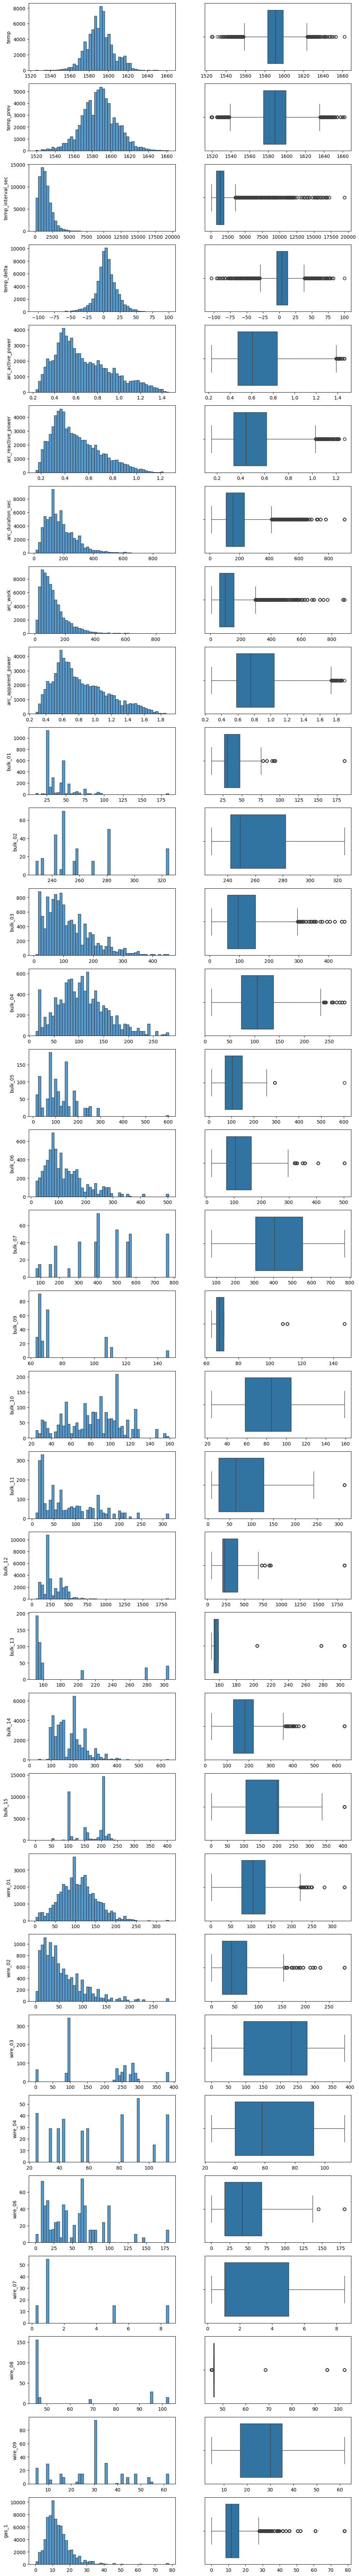

In [44]:
plot_num_cont(data_all_nans)

### Корреляция между признаками

,temp,temp_prev,temp_interval_sec,temp_delta,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
temp,1.000000,0.573051,0.068847,0.169889,0.015419,0.012463,0.002183,0.006733,0.014401,-0.082995,-0.080737,-0.020270,0.012901,0.150512,0.077419,0.412169,-0.044189,0.031759,-0.181060,0.189556,0.186711,0.051299,0.149177,0.312896,-0.166028,-0.024963,-0.229406,-0.127553,0.269515,0.087862,-0.064484,0.045263
temp_prev,0.573051,1.000000,0.144118,-0.718634,0.007452,0.007054,-0.155079,-0.123501,0.007318,0.029965,0.039907,-0.026760,-0.039054,0.216103,0.101949,0.205464,0.132849,-0.047091,-0.147951,0.062467,0.148138,-0.033409,0.017400,0.271835,-0.049891,-0.400547,-0.240302,0.042853,0.334807,0.456875,0.015033,0.083427
temp_interval_sec,0.068847,0.144118,1.000000,-0.119213,0.007423,0.005557,0.129932,0.108200,0.006832,0.067351,-0.038934,-0.001045,-0.037240,-0.056057,0.135980,-0.101793,0.459512,-0.038064,0.007138,0.150767,-0.136790,0.147788,0.109082,0.104972,0.109437,-0.500683,-0.055692,0.166895,-0.510271,0.581986,0.105040,0.276990
temp_delta,0.169889,-0.718634,-0.119213,1.000000,0.004207,0.002066,0.189456,0.154864,0.003463,-0.096191,-0.119479,0.015754,0.051594,-0.087625,-0.060203,0.255151,-0.174900,0.077718,0.032071,0.087186,-0.029298,0.085882,0.100876,-0.081361,-0.060564,0.378216,0.062473,-0.120948,-0.180096,-0.445303,-0.052088,-0.063658
arc_active_power,0.015419,0.007452,0.007423,0.004207,1.000000,0.966747,0.011423,0.537046,0.995567,0.060777,-0.111684,-0.007418,-0.007223,0.022588,0.025486,0.171303,-0.069006,0.006898,0.023951,0.029664,0.306514,0.007858,0.018852,0.018667,0.022674,-0.020229,0.053903,0.002454,0.057490,0.036923,0.060757,0.011872
arc_reactive_power,0.012463,0.007054,0.005557,0.002066,0.966747,1.000000,0.006604,0.516376,0.986499,0.049745,-0.101936,-0.004244,-0.008864,0.026100,0.021674,0.128458,-0.059222,0.015998,0.009279,0.032043,0.317187,0.008447,0.012305,0.016310,0.028113,-0.002694,0.047181,-0.017530,0.111817,0.005107,0.059825,0.009558
arc_duration_sec,0.002183,-0.155079,0.129932,0.189456,0.011423,0.006604,1.000000,0.793822,0.009724,0.071075,-0.144685,-0.010113,0.022416,-0.131664,-0.000013,0.067526,0.045052,-0.077963,-0.005768,0.119265,-0.165330,0.124799,0.105728,-0.032046,0.004366,-0.041715,0.056430,0.047166,-0.151447,-0.180943,0.059572,0.050127
arc_work,0.006733,-0.123501,0.108200,0.154864,0.537046,0.516376,0.793822,1.000000,0.533624,0.070905,-0.215105,-0.015065,0.010677,-0.087634,0.019236,0.172010,0.060812,-0.060975,0.001605,0.107176,-0.050732,0.097170,0.092275,-0.018768,0.017280,-0.003976,-0.017132,0.097537,-0.035743,-0.136775,0.090966,0.038815
arc_apparent_power,0.014401,0.007318,0.006832,0.003463,0.995567,0.986499,0.009724,0.533624,1.000000,0.057105,-0.109002,-0.006355,-0.007895,0.023969,0.024258,0.156310,-0.065442,0.010135,0.018629,0.030673,0.312943,0.008108,0.016540,0.017940,0.024831,-0.014152,0.050833,-0.004800,0.077532,0.026163,0.061242,0.011084
bulk_01,-0.082995,0.029965,0.067351,-0.096191,0.060777,0.049745,0.071075,0.070905,0.057105,1.000000,-0.134695,-0.066366,-0.008226,-0.652556,-0.039873,-0.254391,NaN,-0.268837,0.826354,0.233864,NaN,0.225194,-0.021985,-0.043225,-0.250072,0.572703,-0.073517,-0.210669,-0.348505,NaN,NaN,0.333167


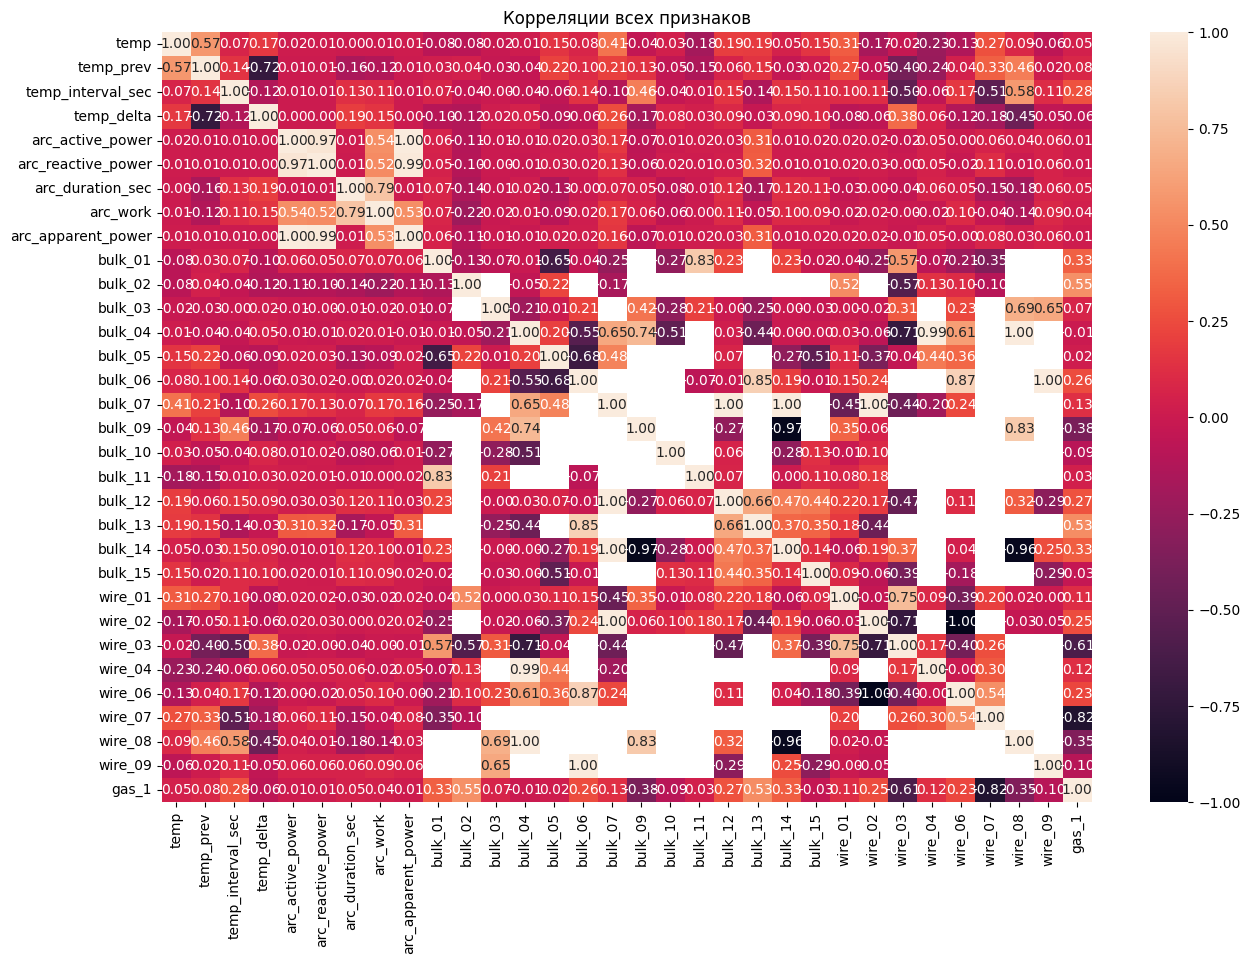

In [45]:
num_col_list = data_all_nans.select_dtypes(include='number').columns.to_list()
corr_matrix = data_all_nans[num_col_list].corr()
plt.figure(figsize=(15, 10))
plot = sns.heatmap(corr_matrix, annot=True, fmt='.2f');
plot.set_title('Корреляции всех признаков');
display(corr_matrix)

In [46]:
corr_matrix[corr_matrix[corr_matrix > 0.9].count() > 1][corr_matrix > 0.9]

,temp,temp_prev,temp_interval_sec,temp_delta,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
arc_active_power,NaN,NaN,NaN,NaN,1.000000,0.966747,NaN,NaN,0.995567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arc_reactive_power,NaN,NaN,NaN,NaN,0.966747,1.000000,NaN,NaN,0.986499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arc_apparent_power,NaN,NaN,NaN,NaN,0.995567,0.986499,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.993869,NaN,NaN,1.0,NaN,NaN
bulk_06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
bulk_07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wire_02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wire_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.993869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN


In [47]:
data_all_nans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74758 entries, 1 to 2499
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp                74758 non-null  float64
 1   temp_prev           74758 non-null  float64
 2   temp_interval_sec   74758 non-null  float64
 3   temp_delta          71679 non-null  float64
 4   arc_active_power    74758 non-null  float64
 5   arc_reactive_power  74758 non-null  float64
 6   arc_duration_sec    74758 non-null  float64
 7   arc_work            74758 non-null  float64
 8   arc_apparent_power  74758 non-null  float64
 9   bulk_01             3052 non-null   float64
 10  bulk_02             291 non-null    float64
 11  bulk_03             12960 non-null  float64
 12  bulk_04             11046 non-null  float64
 13  bulk_05             1160 non-null   float64
 14  bulk_06             6903 non-null   float64
 15  bulk_07             438 non-null    float64
 16  bulk_09   

In [48]:
flds_to_drop = []
# arc_active_power vs arc_reactive_power
flds_to_drop.append('arc_reactive_power')
# arc_active_power vs arc_apparent_power
flds_to_drop.append('arc_apparent_power')
# bulk_04 (11046) vs wire_04 (345) and wire_08 (225)
flds_to_drop.append('wire_04')
flds_to_drop.append('wire_08')
# bulk_06 (6903) vs wire_09 (313)
flds_to_drop.append('wire_09')
# bulk_07 (438) vs bulk_12 (33598) and bulk_14 (45504) and wire_02 (12738)
flds_to_drop.append('bulk_07')
# wire_09 (313) vs bulk_06 (6903)
flds_to_drop.append('wire_09')
flds_to_drop

['arc_reactive_power',
 'arc_apparent_power',
 'wire_04',
 'wire_08',
 'wire_09',
 'bulk_07',
 'wire_09']

## Обучение

In [54]:
class Learn:
	random_state_	= 61026
	test_fraction_	= 0.25
	target_fld_		= 'temp_delta'
	drop_fld_		= ['temp', 'temp_delta'] + flds_to_drop

	def __init__(self, df):
		df_wt_key = df.reset_index(drop=True)
		x = df_wt_key.drop(columns=Learn.drop_fld_)
		y = df_wt_key[Learn.target_fld_]
		self.x_train_, self.x_test_, self.y_train_, self.y_test_ =\
			train_test_split(x, y, test_size=Learn.test_fraction_, random_state=Learn.random_state_)
		self.pipe_lin_reg_ = None
		self.pipe_elastic_net_ = None
		self.pipe_tree_ = None
		self.gradient_boost_ = None

	def linear_regression(self):
		if not self.pipe_lin_reg_:
			self.pipe_lin_reg_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				#('estimator', LinearRegression())
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						LinearRegression(),
						{},
						cv=5,
						random_state=Learn.random_state_,
						n_trials=1
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_lin_reg_

	def elastic_net(self):
		if not self.pipe_elastic_net_:
			self.pipe_elastic_net_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					ElasticNetCV(
						l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
						alphas=100,
						cv=5,
						random_state=Learn.random_state_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_elastic_net_

	def decision_tree(self):
		if not self.pipe_tree_:
			self.pipe_tree_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						DecisionTreeRegressor(random_state=Learn.random_state_),
						{
							'max_depth': optuna.distributions.IntDistribution(1, 20, step=1)
						},
						cv=5,
						random_state=Learn.random_state_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_tree_

	def gradient_boost(self):
		if not self.gradient_boost_:
			self.gradient_boost_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					GradientBoostingRegressor(
						loss='absolute_error',
						random_state=Learn.random_state_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.gradient_boost_

	def explore(self, estimator, x, y, label):
		print(f'{label} R2: {estimator.score(x, y):.04f}')
		y_pred = estimator.predict(x)
		print(f'{label} MAE: {mean_absolute_error(y, y_pred):.04f}')
		y_df = pd.DataFrame({'y_true': y, 'y_pred': y_pred})
		y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']

		fig, axs = plt.subplots(2, 2, figsize=(15, 10))
		sns.scatterplot(y_df, x='y_true', y='y_pred', ax=axs[0, 0]).set_title(f'{label}. Предсказания в пространстве таргета');
		sns.scatterplot(y_df, x='y_true', y='y_error', ax=axs[0, 1]).set_title(f'{label}. Ошибки в пространстве таргета');
		sns.histplot(y_df, x='y_error', ax=axs[1, 0]).set_title(f'{label}. Гистограмма ошибок');
		sns.boxplot(y_df, x='y_error', ax=axs[1, 1]).set_title(f'{label}. Ящик ошибок');

	def explore_train(self, estimator, label):
		self.explore(estimator, self.x_train_, self.y_train_, label + '.train')

	def explore_test(self, estimator, label):
		self.explore(estimator, self.x_test_, self.y_test_, label + '.test')

learn = Learn(data_all)

/tmp/ipykernel_1734417/2792765645.py:26: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-12 20:28:44,823] A new study created in memory with name: no-name-3c567c06-cc0e-44b4-bec0-40406e8fbce5
[I 2025-10-12 20:28:49,840] Trial 0 finished with value: 0.6055705622830013 and parameters: {}. Best is trial 0 with value: 0.6055705622830013.


LinearRegression.train R2: 0.6117
LinearRegression.train MAE: 7.4683
ElasticNet.train R2: 0.6076
ElasticNet.train MAE: 7.5095


/tmp/ipykernel_1734417/2792765645.py:61: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-12 20:29:09,041] A new study created in memory with name: no-name-11bda6bc-de14-4865-95bc-4b57a93141a5
[I 2025-10-12 20:29:17,392] Trial 0 finished with value: 0.433276997576124 and parameters: {'max_depth': 2}. Best is trial 0 with value: 0.433276997576124.
[I 2025-10-12 20:30:02,275] Trial 1 finished with value: 0.7170932923029053 and parameters: {'max_depth': 17}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-12 20:30:28,171] Trial 2 finished with value: 0.6261264180342911 and parameters: {'max_depth': 9}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-12 20:30:31,657] Trial 3 finished with value: 0.28020225251135916 and parameters: {'max_depth': 1}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-12 20:31:04,890] Trial 4 finished with value: 0

DecisionTreeRegressor.train R2: 0.8787
DecisionTreeRegressor.train MAE: 3.4025
GradientBoostingRegressor.train R2: 0.6264
GradientBoostingRegressor.train MAE: 7.0957


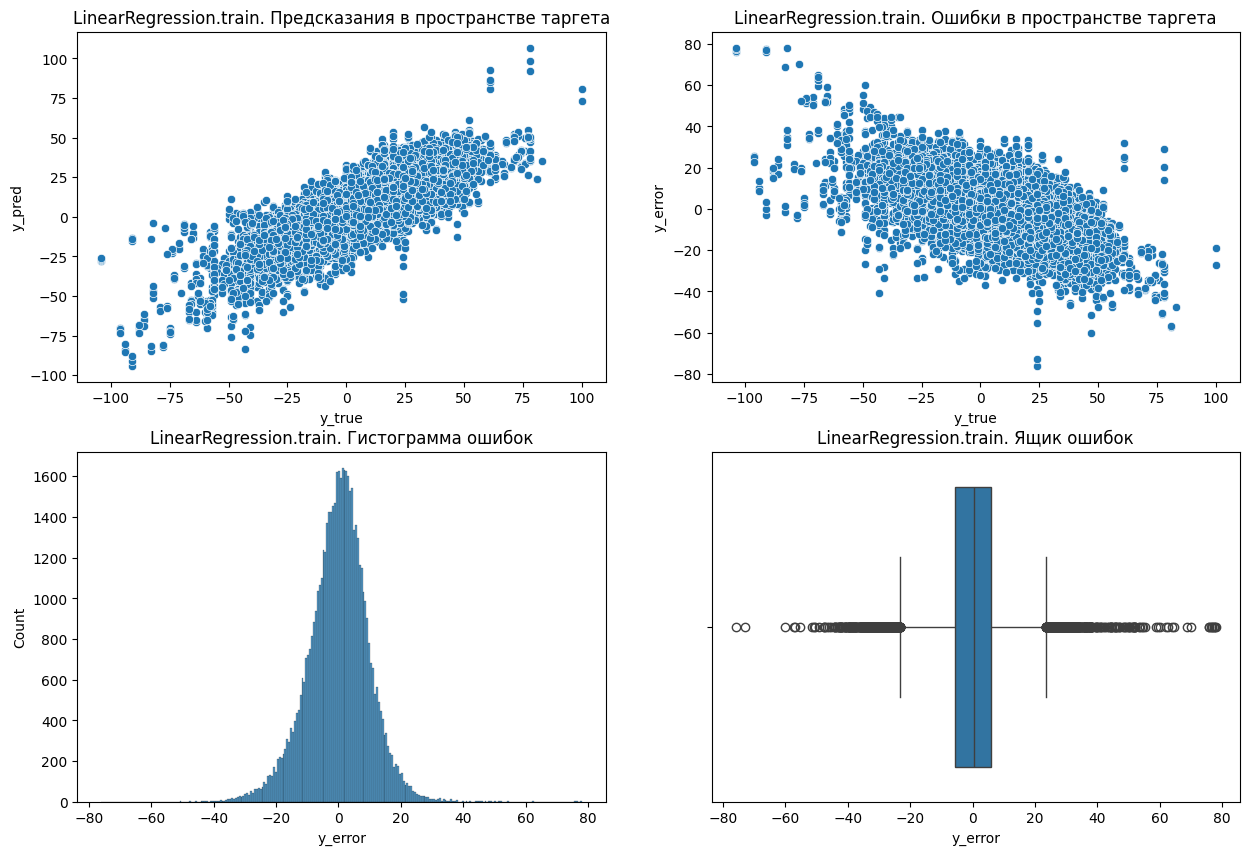

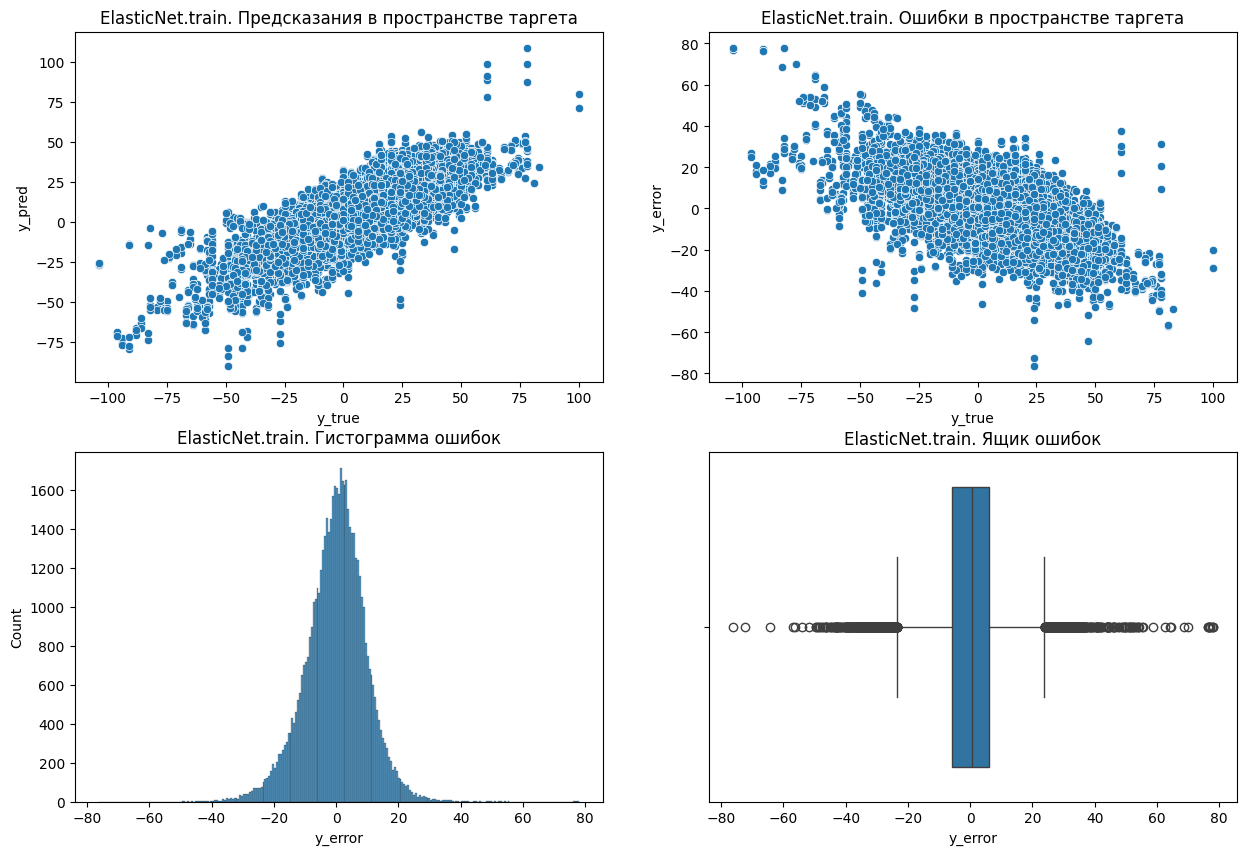

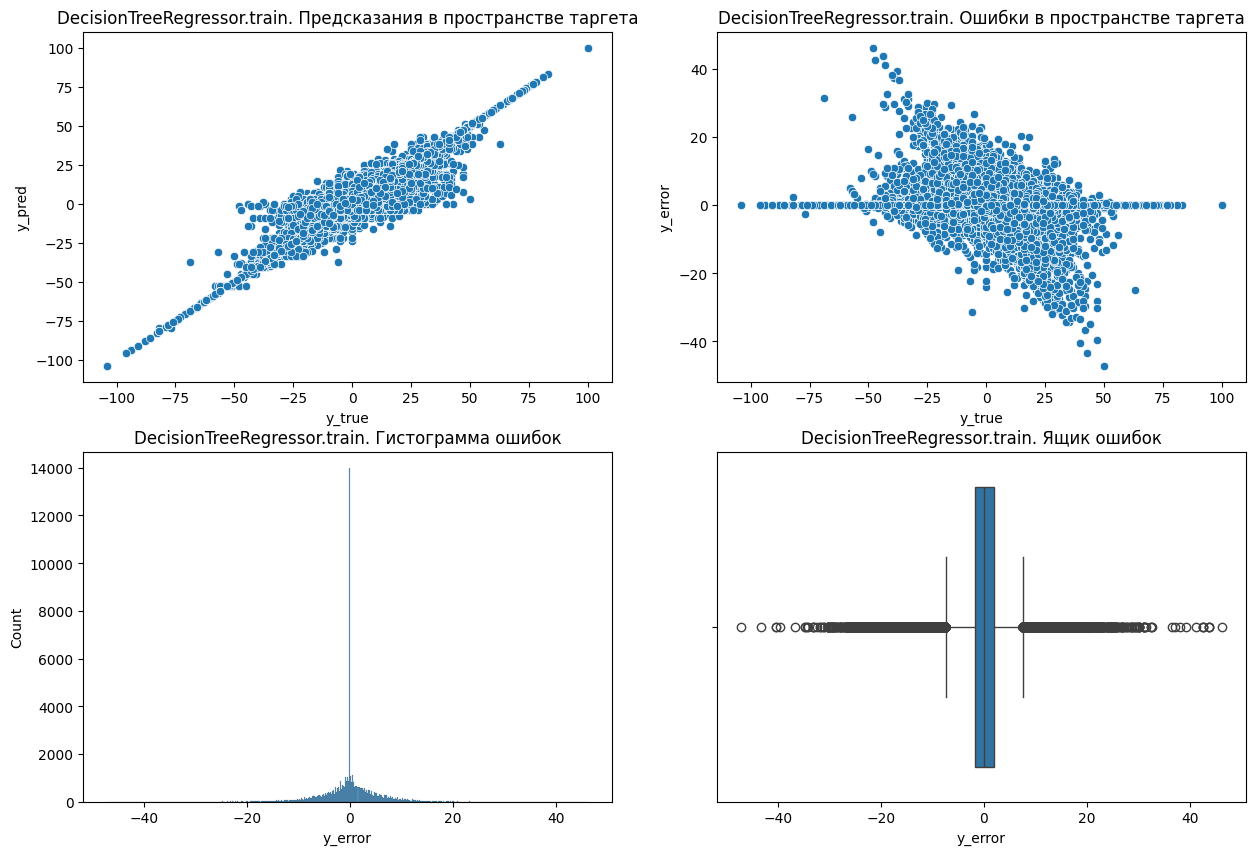

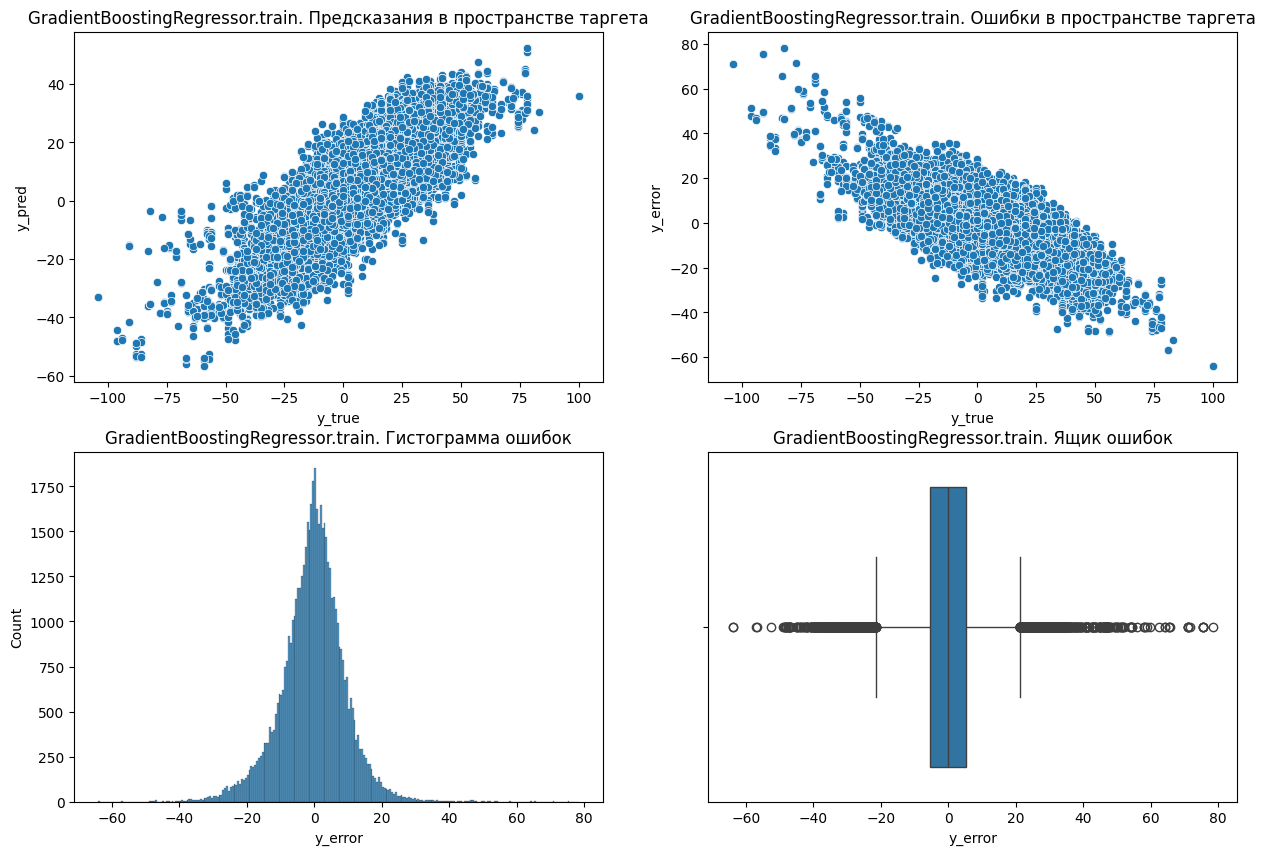

In [55]:
learn.explore_train(learn.linear_regression(), 'LinearRegression')
learn.explore_train(learn.elastic_net(), 'ElasticNet')
learn.explore_train(learn.decision_tree(), 'DecisionTreeRegressor')
learn.explore_train(learn.gradient_boost(), 'GradientBoostingRegressor')


In [51]:
data_all['temp_delta'].describe()

count    74758.000000
mean         4.204714
std         15.888603
min       -104.000000
25%         -4.000000
50%          4.000000
75%         13.000000
max        100.000000
Name: temp_delta, dtype: float64

In [52]:
y_df = pd.DataFrame({'y_true': learn.y_train_, 'y_pred': learn.decision_tree().predict(learn.x_train_)})
y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']
y_df = y_df.merge(learn.x_train_, left_index=True, right_index=True, how='inner')
y_df.query('abs(y_error) < 0.1')

,y_true,y_pred,y_error,temp_prev,temp_interval_sec,arc_active_power,arc_duration_sec,arc_work,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_06,wire_07,gas_1
17177,23.0,23.0,0.0,1568.0,786.0,0.281762,149.0,41.982538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,0.0,136.0,224.0,124.253997,0.000000,0.0,0.0,0.0,6.696740
24605,12.0,12.0,0.0,1573.0,1890.0,0.778034,137.0,106.590658,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,153.0,0.0,153.0,154.0,193.377594,0.000000,0.0,0.0,0.0,17.293232
19690,16.0,16.0,0.0,1565.0,2769.0,0.455800,260.0,118.508000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,393.0,0.0,213.0,188.0,123.130799,0.000000,0.0,0.0,0.0,9.909262
73548,20.0,20.0,0.0,1577.0,1099.0,0.401085,71.0,28.477035,0.0,0.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,361.0,0.0,235.0,0.0,0.000000,0.000000,0.0,0.0,0.0,11.059257
43917,-10.0,-10.0,0.0,1631.0,2683.0,0.647044,152.0,98.350688,0.0,0.0,71.0,199.0,0.0,0.0,0.0,0.0,0.0,412.0,0.0,201.0,205.0,0.000000,0.000000,0.0,0.0,0.0,11.615588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29582,21.0,21.0,0.0,1576.0,287.0,1.013087,214.0,216.800618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.0,0.000000,0.000000,0.0,0.0,0.0,10.671592
71153,4.0,4.0,0.0,1562.0,1804.0,0.367869,135.0,49.662315,0.0,0.0,43.0,0.0,0.0,23.0,0.0,0.0,0.0,105.0,0.0,110.0,0.0,0.000000,0.000000,0.0,0.0,0.0,16.309071
6022,-17.0,-17.0,0.0,1603.0,1709.0,0.798544,140.0,111.796160,0.0,0.0,0.0,0.0,0.0,178.0,0.0,0.0,0.0,305.0,0.0,160.0,203.0,121.211998,18.170881,0.0,0.0,0.0,7.972122
41919,2.0,2.0,0.0,1563.0,1109.0,0.831907,254.0,211.304378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,204.0,135.064804,0.000000,0.0,0.0,0.0,10.655252


DecisionTreeRegressor.test R2: 0.7597
DecisionTreeRegressor.test MAE: 4.9022


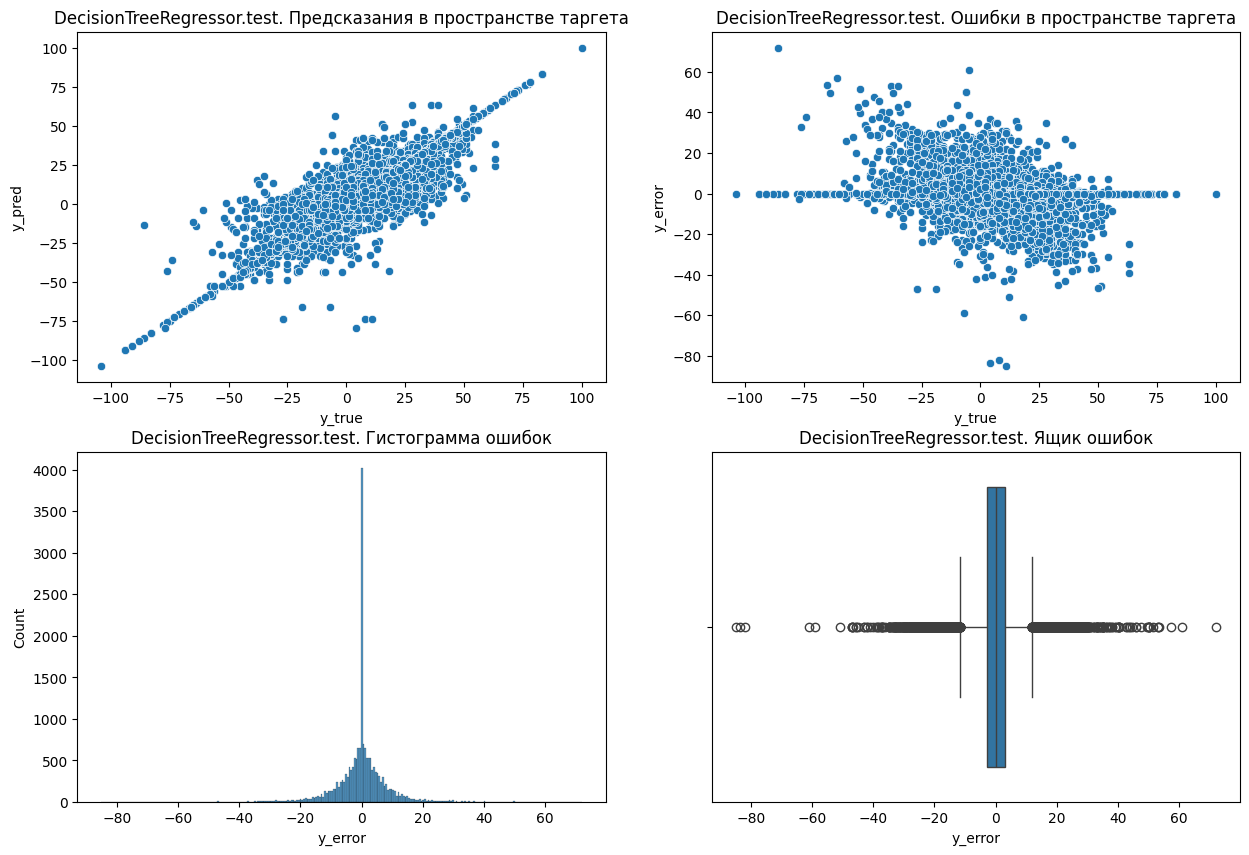

In [53]:
learn.explore_test(learn.decision_tree(), 'DecisionTreeRegressor')